Exploratory Data Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load the cleaned dataset


In [4]:
df = pd.read_csv("../data/processed/heart_cleaned.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


1. Dataset Overview


In [5]:
df.shape

(302, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Target Variable Analysis


In [8]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

Calculate the correlation matrix

In [9]:
correlation = df.corr()

Create the heatmap

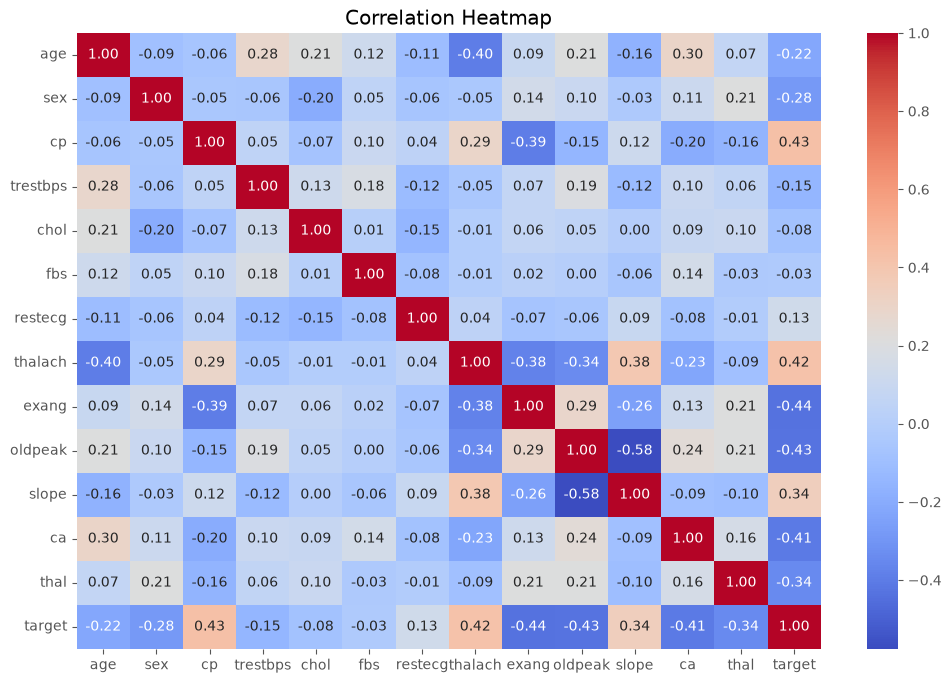

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Report example

Correlation Heatmap of the Heart Disease Dataset.

The correlation heatmap illustrates the linear relationships among all variables in the dataset. Features such as chest pain type (cp) and maximum heart rate (thalach) show stronger correlations with the target variable, while cholesterol (chol) exhibits a weaker linear correlation. These findings help identify potentially informative features for the machine learning models.

Age Distribution

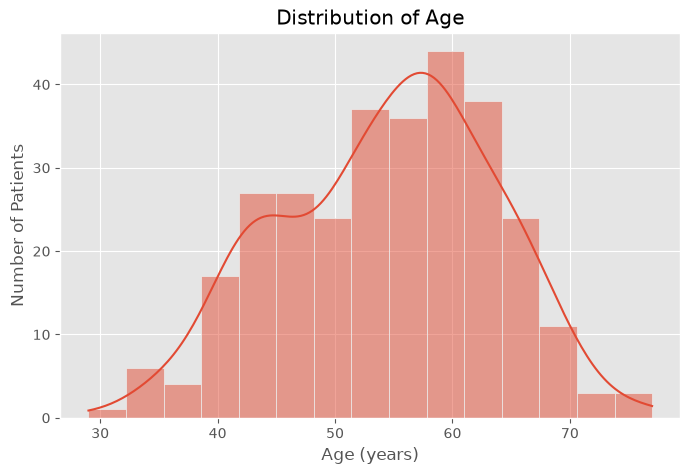

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=15, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

plt.show()

<Axes: xlabel='age', ylabel='Count'>

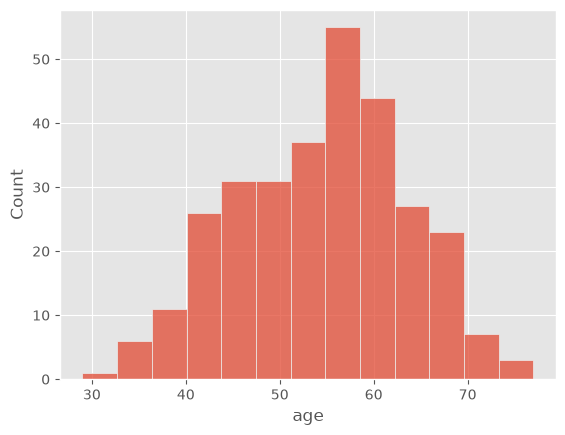

In [14]:
sns.histplot(df["age"])

Distribution of Patient Age

The histogram illustrates the distribution of patient ages in the dataset. Most patients are concentrated within the middle-aged group, while relatively fewer younger and older patients are represented. Understanding the age distribution is important because age is a well-established risk factor for heart disease.

Graph 2: Target Variable Distribution

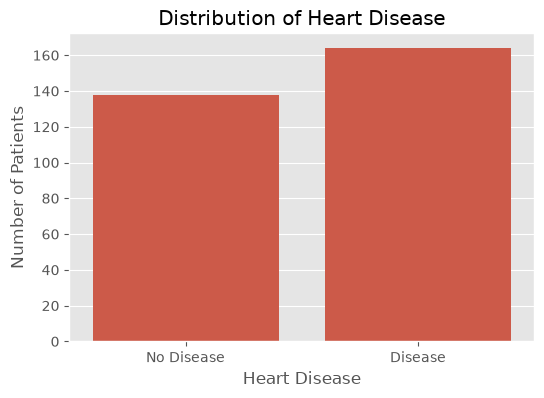

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="target")

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No Disease", "Disease"])

plt.show()

Graph 3: Heart Disease by Sex

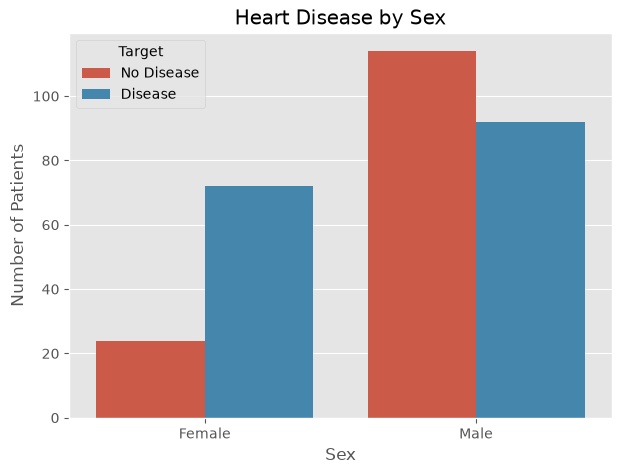

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="sex", hue="target")

plt.title("Heart Disease by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["Female", "Male"])

plt.legend(title="Target", labels=["No Disease", "Disease"])

plt.show()

Graph 4: Chest Pain Type vs Heart Disease

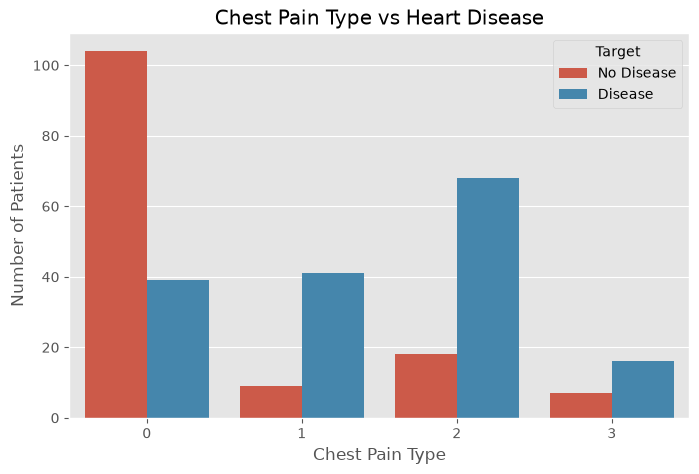

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="cp", hue="target")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(title="Target", labels=["No Disease", "Disease"])

plt.show()

Graph 5: Cholesterol Distribution

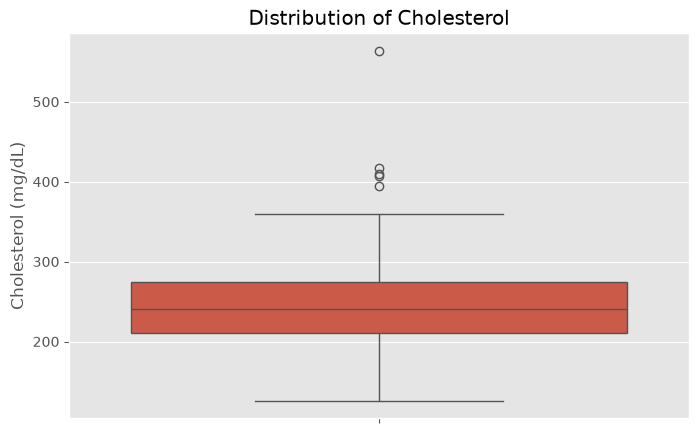

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["chol"])

plt.title("Distribution of Cholesterol")

plt.ylabel("Cholesterol (mg/dL)")

plt.show()

Graph 6: Blood Pressure Distribution

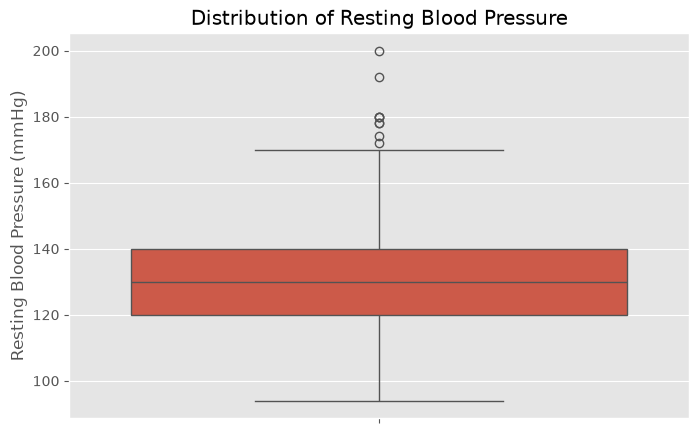

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["trestbps"])

plt.title("Distribution of Resting Blood Pressure")

plt.ylabel("Resting Blood Pressure (mmHg)")

plt.show()

Graph 7: Maximum Heart Rate by Heart Disease

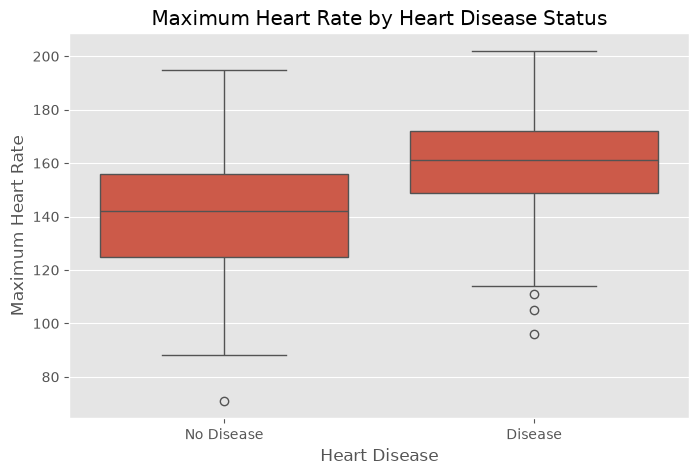

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="thalach")

plt.title("Maximum Heart Rate by Heart Disease Status")

plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.xticks([0,1], ["No Disease", "Disease"])

plt.show()